In [1]:
import sqlite3, pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.timeseries import LombScargle
import astropy.units as u
from astropy.time import Time
from matplotlib.widgets import Button
from matplotlib.widgets import TextBox
from matplotlib.widgets import RadioButtons
import matplotlib.ticker as mtick
%matplotlib ipympl 

In [2]:
con = sqlite3.connect('rubin_obs_orbits.sqlite')

In [3]:
stop = '2025-06-01T00:00:00'
tstp = Time(stop, format='isot', scale='utc')
tstp.mjd

np.float64(60827.0)

In [4]:
#cmd = f"select distinct provid, a,e, incl from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where e < 1 and a >= 1.6 and a <= 4.2 and a/(1-e)>=1.3 and mjd_utc < {tstp.mjd}"
cmd = "select distinct provid, a,e, incl from  obs_sbn inner join mpc_orbits on obs_sbn.provid=mpc_orbits.fullDesignation where e < 1 and a >=20"

lsst_discovery_orbits = pd.read_sql_query(cmd, con)


In [5]:
ast_provid = lsst_discovery_orbits['provid'].to_numpy()

In [6]:
    
def plot_ast(obj, ax):

    ax.cla()
    start=-1

    cmd = f"select mjd_utc,mag,rmsmag from obs_sbn where provid='{obj}' and band='Lr'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))
    df = df.astype({'mag': float, 'rmsmag': float})
    ax.invert_yaxis()
    ax.set_title(f"{obj}")
    ax.set_xlabel("days from first obs")
    ax.set_ylabel("apparent mag")

    if (len(df) > 0):
    
        if (start==-1):
            start= df.iloc[0]['mjd_utc']

        ax.errorbar(df['mjd_utc']-start, df['mag'], yerr=df['rmsmag'], fmt="o", color='red')


    cmd = f"select mjd_utc,mag,rmsmag from obs_sbn where provid='{obj}'  and band='Lg'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))

    df = df.astype({'mag': float, 'rmsmag': float})
    if (len(df) > 0):
       
        if (start==-1):
            start= df.iloc[0]['mjd_utc']

        ax.errorbar(df['mjd_utc']-start, df['mag'], yerr=df['rmsmag'], fmt="o", color='green')


    cmd = f"select mjd_utc,mag,rmsmag from obs_sbn where provid='{obj}' and band='Li'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))
    df = df.astype({'mag': float, 'rmsmag': float})
    if (len(df) > 0):
       
        if (start==-1):
            start= df.iloc[0]['mjd_utc']

        ax.errorbar(df['mjd_utc']-start, df['mag'], yerr=df['rmsmag'], fmt="o", color='pink')

    cmd = f"select mjd_utc,mag,rmsmag from obs_sbn where provid='{obj}' and band='Lz'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))
    df = df.astype({'mag': float, 'rmsmag': float})
    if (len(df) > 0):
       
        if (start==-1):
            start= df.iloc[0]['mjd_utc']
        ax.errorbar(df['mjd_utc']-start, df['mag'], yerr=df['rmsmag'], fmt="o", color='purple')



In [7]:
def plot_dist(obj, ax):

    ax.cla()
    start=-1

    cmd = f"select mjd_utc,Obj_Sun_LTC_au, Range_LTC_au  from obs_sbn where provid='{obj}' and band='Lr'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))
    df = df.astype({'Obj_Sun_LTC_au': float, 'Range_LTC_au': float})
    ax.invert_yaxis()
    ax.set_title(f"{obj}")
    ax.set_xlabel("days from first obs")
    ax.set_ylabel("distance (au)")
    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))

    if (len(df) > 0):
    
        if (start==-1):
            start= df.iloc[0]['mjd_utc']

        ax.plot(df['mjd_utc']-start, df['Obj_Sun_LTC_au'], "o", color='red')


    cmd = f"select mjd_utc,Obj_Sun_LTC_au, Range_LTC_au from obs_sbn where provid='{obj}'  and band='Lg'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))

    df = df.astype({'Obj_Sun_LTC_au': float, 'Range_LTC_au': float})
    if (len(df) > 0):
       
        if (start==-1):
            start= df.iloc[0]['mjd_utc']

        ax.plot(df['mjd_utc']-start, df['Obj_Sun_LTC_au'], "o", color='green')


    cmd = f"select mjd_utc,Obj_Sun_LTC_au, Range_LTC_au from obs_sbn where provid='{obj}'  and band='Li'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))

    df = df.astype({'Obj_Sun_LTC_au': float, 'Range_LTC_au': float})
    if (len(df) > 0):
       
        if (start==-1):
            start= df.iloc[0]['mjd_utc']

        ax.plot(df['mjd_utc']-start, df['Obj_Sun_LTC_au'], "o", color='pink')

    cmd = f"select mjd_utc,Obj_Sun_LTC_au, Range_LTC_au from obs_sbn where provid='{obj}'  and band='Lz'"
    df = pd.read_sql_query(cmd, con)
    print(len(df))

    df = df.astype({'Obj_Sun_LTC_au': float, 'Range_LTC_au': float})
    if (len(df) > 0):
       
        if (start==-1):
            start= df.iloc[0]['mjd_utc']

        ax.plot(df['mjd_utc']-start, df['Obj_Sun_LTC_au'], "o", color='purple')

In [8]:
def plot_phasecurve(obj, ax):

    ax.cla()
    cmd = f"select mjd_utc,mag,rmsmag, phase_deg, Obj_Sun_LTC_au, Range_LTC_au from obs_sbn where provid='{obj}' and band='Lr'"
    df = pd.read_sql_query(cmd, con)
    df = df.astype({'phase_deg': float, 'mag': float, 'rmsmag': float, 'Obj_Sun_LTC_au':float, 'Range_LTC_au': float})

    
    ax.invert_yaxis()
    ax.set_title(f"{obj}")
    ax.set_xlabel("phase")
    ax.set_ylabel("reduced mag")


    if (len(df) > 0):
        df["cmag"] = df["mag"] - 5*np.log10(df["Range_LTC_au"]*df["Obj_Sun_LTC_au"])

        ax.errorbar(df['phase_deg'], df['cmag'], yerr=df['rmsmag'], fmt="o", color='red')



    cmd = f"select mjd_utc,mag,rmsmag, phase_deg, Obj_Sun_LTC_au, Range_LTC_au from obs_sbn where provid='{obj}'  and band='Lg'"
    df = pd.read_sql_query(cmd, con)

    df = df.astype({'phase_deg': float, 'mag': float, 'rmsmag': float, 'Obj_Sun_LTC_au':float, 'Range_LTC_au': float})

    if (len(df) > 0):
        df["cmag"] = df["mag"] - 5*np.log10(df["Range_LTC_au"]*df["Obj_Sun_LTC_au"])

        ax.errorbar(df['phase_deg'], df['cmag'], yerr=df['rmsmag'], fmt="o", color='green')


    cmd = f"select mjd_utc,mag,rmsmag, phase_deg, Obj_Sun_LTC_au, Range_LTC_au from obs_sbn where provid='{obj}' and band='Li'"
    df = pd.read_sql_query(cmd, con)

    df = df.astype({'phase_deg': float, 'mag': float, 'rmsmag': float, 'Obj_Sun_LTC_au':float, 'Range_LTC_au': float})

    if (len(df) > 0):
        df["cmag"] = df["mag"] - 5*np.log10(df["Range_LTC_au"]*df["Obj_Sun_LTC_au"])

        ax.errorbar(df['phase_deg'], df['cmag'], yerr=df['rmsmag'], fmt="o", color='pink')

    cmd = f"select mjd_utc,mag,rmsmag, phase_deg, Obj_Sun_LTC_au, Range_LTC_au from obs_sbn where provid='{obj}' and band='Lz'"
    df = pd.read_sql_query(cmd, con)
    
    df = df.astype({'phase_deg': float, 'mag': float, 'rmsmag': float, 'Obj_Sun_LTC_au':float, 'Range_LTC_au': float})

    if (len(df) > 0):
        df["cmag"] = df["mag"] - 5*np.log10(df["Range_LTC_au"]*df["Obj_Sun_LTC_au"])

        ax.errorbar(df['phase_deg'], df['cmag'], yerr=df['rmsmag'], fmt="o", color='purple')


In [9]:
class Buttons:
    ind = 0
    ax = None
    
    def __init__(self, ax):
        self.ax=ax
        self.ind=0

    def next(self, event):
        self.ind += 1
        obj=ast_provid[self.ind]
        plot_ast(obj,self.ax)
    
    def prev(self, event):
        self.ind -= 1
        obj=ast_provid[self.ind]
        plot_ast(obj,self.ax)

    def dist(self, event):
        val=self.ax.get_title()

        w=ast_provid == val
        if(len(ast_provid[w]) > 0):
            index=np.arange(len(ast_provid))
            self.ind=index[w][0]
            obj=ast_provid[self.ind]
            plot_dist(obj,self.ax)
    def phase(self, event):
        val=self.ax.get_title()

        w=ast_provid == val
        if(len(ast_provid[w]) > 0):
            index=np.arange(len(ast_provid))
            self.ind=index[w][0]
            obj=ast_provid[self.ind]
            plot_phasecurve(obj,self.ax)

    def lc(self, event):
        val=self.ax.get_title()

        w=ast_provid == val
        if(len(ast_provid[w]) > 0):
            index=np.arange(len(ast_provid))
            self.ind=index[w][0]
            obj=ast_provid[self.ind]
            plot_ast(obj,self.ax)
        

In [10]:
class Box:
    ax = None
    
    def __init__(self, ax,):
        self.ax=ax

    def submit(self, val):
        print(val)
        w=ast_provid == val
        if(len(ast_provid[w]) > 0):
            obj=ast_provid[w][0]
            plot_ast(obj,self.ax)
        
    

2010 PK66
11
2
12
3


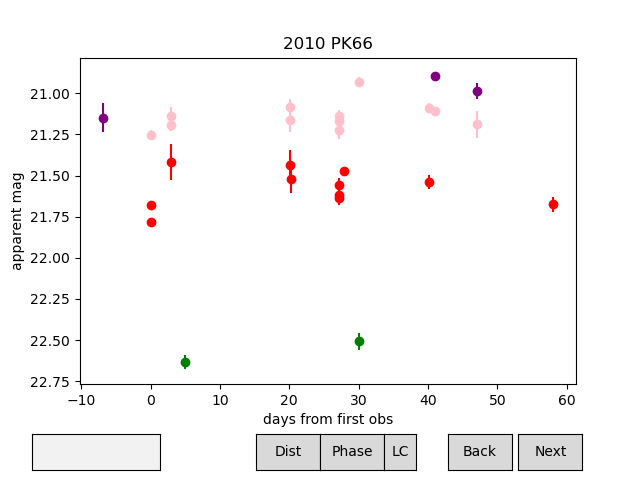

In [11]:
# not seeding as it should use the entropy of the system to init

#rng=np.random.default_rng()
#index=rng.integers(low=0, high=len(ast_provid), size=1) 


obj=ast_provid[0]
print(obj)

fig,ax =plt.subplots()
plot_ast(obj,ax)
fig.subplots_adjust(bottom=0.2)

axdist = fig.add_axes([0.4, 0.02, 0.1, 0.075])
axphase = fig.add_axes([0.5, 0.02, 0.1, 0.075])
axlc = fig.add_axes([0.6, 0.02, 0.05, 0.075])
axprev = fig.add_axes([0.7, 0.02, 0.1, 0.075])
axnext = fig.add_axes([0.81, 0.02, 0.1, 0.075])
textb = fig.add_axes([0.05, 0.02, 0.2, 0.075])

callback = Buttons(ax)
bnext = Button(axnext, 'Next')
bnext.on_clicked(callback.next)
bprev = Button(axprev, 'Back')
bprev.on_clicked(callback.prev)
bphase = Button(axphase, 'Phase')
bphase.on_clicked(callback.phase)
blc = Button(axlc, 'LC')
blc.on_clicked(callback.lc)
bdist = Button(axdist, 'Dist')
bdist.on_clicked(callback.dist)

box=Box(ax)
text_box = TextBox(textb, "", textalignment="center")
text_box.on_submit(box.submit)


plt.show()

In [12]:
con = sqlite3.connect('rubin_obs_orbits.sqlite')

cmd = "select obstime,  mjd_utc,  provid, mag, rmsmag, band, phase_deg, Obj_Sun_LTC_au, Range_LTC_au ,ra, dec, a,e, incl from  obs_sbn inner join mpc_orbits on band='Li' and obs_sbn.provid=mpc_orbits.fullDesignation and provid='2024 LY9'"

df= pd.read_sql_query(cmd, con)
df["cmag"] = df["mag"] - 5*np.log10(df["Range_LTC_au"]*df["Obj_Sun_LTC_au"])

df

,obstime,mjd_utc,provid,mag,rmsmag,band,phase_deg,Obj_Sun_LTC_au,Range_LTC_au,ra,dec,a,e,incl,cmag
0,2025-06-21T06:06:08.244000,60847.254262,2024 LY9,21.306,0.0329,Li,3.639500,11.051439,10.293875,312.698846,-8.570513,60.209376,0.839178,146.09859,11.026011
1,2025-07-07T02:42:53.472000,60863.113119,2024 LY9,21.316,0.0743,Li,2.430868,11.014454,10.101576,311.072319,-9.210589,60.209376,0.839178,146.09859,11.084239
2,2025-07-21T03:43:43.177000,60877.155361,2024 LY9,21.159,0.0229,Li,1.258924,10.982023,9.992329,309.445350,-9.871914,60.209376,0.839178,146.09859,10.957255
3,2025-07-29T08:33:57.451000,60885.356915,2024 LY9,21.107,0.0279,Li,0.779497,10.963221,9.957902,308.450561,-10.289110,60.209376,0.839178,146.09859,10.916470
